# Singapore USEP: Merit Order Analysis (January 2023)

Goal:rebuild the Uniform Singapore Energy Price (USEP) from the offer stacks (merit order) and system demand, then compare it with the published USEP.

Steps 1) Load and clean, 2) Plot the merit order, 3) Clearing-price function and unit tests, 4) Back-test, 5) quey SQLite 
Note: period 1 = 00:00-00:30, so each timestamp is the *start* of its half-hour.

Note: period 1 = 00:00-00:30, so each timestamp is the *start* of its half-hour.

## Table of Contents
1. [Load and clean the data](#sec1)
2. [Export the clean CSVs](#sec1b)
3. [Data-quality checks and findings](#sec1c)
4. [Merit-order plots](#sec2)
5. [Clearing-price function and unit tests](#sec3)
6. [Bonus: SQLite Connection](#sec4)
   - [Load the original files](#sec4a)
   - [Clean in SQL](#sec4c)
   - [Analysis queries](#sec4d)
   - [Join tables](#sec4e)
7. [Summary](#sec6)

<a id="sec1"></a>
## 1. Load and clean the data 

In [103]:
#Import all the required lybreries
import re, math, unittest
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.2f}".format
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

DATA = Path.cwd()
DelayedOffer = "DelayedOfferStacks_Energy_01-Jan-2023 to 31-Jan-2023.csv"
USEP = "USEP_Jan-2023.csv"


In [104]:
#read raw file
raw_m = pd.read_csv(DelayedOffer)
raw_m.info()
raw_m.head()

C:\Users\devik\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3071: DtypeWarning: Columns (1,2,3) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206579 entries, 0 to 206578
Data columns (total 4 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   Delayed Offer Stacks_Energy  206578 non-null  object
 1   Unnamed: 1                   206578 non-null  object
 2   Unnamed: 2                   206578 non-null  object
 3   Unnamed: 3                   206578 non-null  object
dtypes: object(4)
memory usage: 6.3+ MB


,Delayed Offer Stacks_Energy,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,Date,Period,Lowest to Highest Offer Price ($/MWh),Total Offer Capacity At Specified Offer Price ...
2,01-JAN-2023,1,-4750,84.3
3,01-JAN-2023,1,-4500,324
4,01-JAN-2023,1,-90,854


In [105]:
raw_m = pd.read_csv(DelayedOffer, skiprows=2)
raw_m.head()

,Date,Period,Lowest to Highest Offer Price ($/MWh),Total Offer Capacity At Specified Offer Price (MW)
0,01-JAN-2023,1,"-4,750.00",84.30
1,01-JAN-2023,1,"-4,500.00",324.00
2,01-JAN-2023,1,-90.00,854.00
3,01-JAN-2023,1,-67.00,200.00
4,01-JAN-2023,1,-61.00,280.00


In [106]:
#Read csv file2
raw_u = pd.read_csv(USEP)
raw_u.info()
raw_u.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1488 entries, 0 to 1487
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   INFORMATION TYPE  1488 non-null   object 
 1   DATE              1488 non-null   object 
 2   PERIOD            1488 non-null   int64  
 3   USEP ($/MWh)      1488 non-null   float64
 4   LCP ($/MWh)       1488 non-null   float64
 5   DEMAND (MW)       1488 non-null   float64
 6   TCL (MW)          1488 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 81.5+ KB


,INFORMATION TYPE,DATE,PERIOD,USEP ($/MWh),LCP ($/MWh),DEMAND (MW),TCL (MW)
0,USEP,01 Jan 2023,1,158.62,0.00,"5,539.76",0.00
1,USEP,01 Jan 2023,2,147.58,0.00,"5,443.35",0.00
2,USEP,01 Jan 2023,3,126.83,0.00,"5,384.52",0.00
3,USEP,01 Jan 2023,4,144.53,0.00,"5,367.27",0.00
4,USEP,01 Jan 2023,5,144.51,0.00,"5,331.37",0.00


In [107]:
# evidence for the two bad rows
bad_period = raw_u[raw_u["PERIOD"] > 48]
bad_date = raw_u[pd.to_datetime(raw_u["DATE"], format="%d %b %Y", errors="coerce").isna()]
display(bad_period); display(bad_date)
for i in list(bad_period.index) + list(bad_date.index):
    display(raw_u.loc[i - 2:i + 2])

,INFORMATION TYPE,DATE,PERIOD,USEP ($/MWh),LCP ($/MWh),DEMAND (MW),TCL (MW)
314,USEP,07 Jan 2023,99,"99,999.00",9.99,"9,999.27",10.00


,INFORMATION TYPE,DATE,PERIOD,USEP ($/MWh),LCP ($/MWh),DEMAND (MW),TCL (MW)
985,USEP,40 Jan 2023,26,112.12,0.00,"5,793.26",0.00


,INFORMATION TYPE,DATE,PERIOD,USEP ($/MWh),LCP ($/MWh),DEMAND (MW),TCL (MW)
312,USEP,07 Jan 2023,25,207.58,0.00,"6,155.60",0.00
313,USEP,07 Jan 2023,26,216.70,0.00,"6,162.88",0.00
314,USEP,07 Jan 2023,99,"99,999.00",9.99,"9,999.27",10.00
315,USEP,07 Jan 2023,28,194.04,0.00,"6,136.51",0.00
316,USEP,07 Jan 2023,29,181.56,0.00,"6,148.99",0.00


,INFORMATION TYPE,DATE,PERIOD,USEP ($/MWh),LCP ($/MWh),DEMAND (MW),TCL (MW)
983,USEP,21 Jan 2023,24,112.15,0.00,"5,802.25",0.00
984,USEP,21 Jan 2023,25,111.55,0.00,"5,755.96",0.00
985,USEP,40 Jan 2023,26,112.12,0.00,"5,793.26",0.00
986,USEP,21 Jan 2023,27,112.16,0.00,"5,832.33",0.00
987,USEP,21 Jan 2023,28,123.88,0.00,"5,887.15",0.00


In [110]:
#Clean the files and rename the lables
PERIODS_PER_DAY, SENTINEL_PERIOD = 48, 99

def to_snake(name):
    """'USEP ($/MWh)' -> 'usep', 'INFORMATION TYPE' -> 'information_type'."""
    name = re.sub(r"\(.*?\)", "", str(name))
    name = re.sub(r"[^0-9a-zA-Z]+", "_", name.strip())
    return name.strip("_").lower()

def add_datetime_index(df, date_col="date", period_col="period"):
    """Index by the START of each half-hour: period 1 -> 00:00, period 48 -> 23:30."""
    out = df.copy()
    start = pd.to_datetime(out[date_col]).dt.normalize() + pd.to_timedelta(
        (out[period_col].astype(int) - 1) * 30, unit="m")
    out.index = pd.DatetimeIndex(start, name="datetime")
    return out

def load_delayedoffer(path):
    raw = pd.read_csv(path, skiprows=2)
    raw.columns = ["date", "period", "bid_price", "bid_volume"]
    df = raw.copy()
    df["date"] = pd.to_datetime(df["date"], format="%d-%b-%Y", errors="coerce")
    for c in ("period", "bid_price", "bid_volume"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().drop_duplicates()
    df = df[df["period"].between(1, PERIODS_PER_DAY) & (df["bid_volume"] > 0)].copy()
    df["period"] = df["period"].astype(int)
    df = df.sort_values(["date", "period", "bid_price"], kind="stable")
    df["cum_volume"] = df.groupby(["date", "period"])["bid_volume"].cumsum()
    return add_datetime_index(df)

def load_usep(path):
    raw = pd.read_csv(path)
    raw.columns = [to_snake(c) for c in raw.columns]
    df = raw.copy()
    df["date"] = df["date"].astype(str)

    # 1. impossible date -> date of the previous valid row
    parsed = pd.to_datetime(df["date"], format="%d %b %Y", errors="coerce")
    df["date_fixed"] = parsed.isna()
    df["date"] = parsed.fillna(parsed.ffill())

    # 2. placeholder period 99 -> previous period + 1; fake values -> NaN
    sentinel = df["period"] == SENTINEL_PERIOD
    df["period_fixed"] = sentinel
    prev_period = df["period"].where(~sentinel).ffill()
    df.loc[sentinel, "period"] = prev_period[sentinel] + 1
    df.loc[sentinel, ["usep", "lcp", "demand", "tcl"]] = np.nan

    df["period"] = df["period"].astype(int)
    df = df.drop_duplicates(["date", "period"], keep="first")
    return add_datetime_index(df).sort_index()

def completeness_report(df, freq="30min"):
    """Half-hour timestamps that should exist but don't."""
    full = pd.date_range(df.index.min().normalize(),
                         df.index.max().normalize() + pd.Timedelta(days=1) - pd.Timedelta(freq),
                         freq=freq)
    return full.difference(df.index.unique())

delayedoffer = load_delayedoffer(DelayedOffer)
usep = load_usep(USEP)
display(delayedoffer.head(3)); display(usep.head(3))


,date,period,bid_price,bid_volume,cum_volume
datetime,,,,,
2023-01-01,2023-01-01,1,"-4,750.00",84.30,84.30
2023-01-01,2023-01-01,1,"-4,500.00",324.00,408.30
2023-01-01,2023-01-01,1,-90.00,854.00,"1,262.30"


,information_type,date,period,usep,lcp,demand,tcl,date_fixed,period_fixed
datetime,,,,,,,,,
2023-01-01 00:00:00,USEP,2023-01-01,1,158.62,0.00,"5,539.76",0.00,False,False
2023-01-01 00:30:00,USEP,2023-01-01,2,147.58,0.00,"5,443.35",0.00,False,False
2023-01-01 01:00:00,USEP,2023-01-01,3,126.83,0.00,"5,384.52",0.00,False,False


<a id="sec1b"></a>
## 2.Export the clean csv file

In [111]:
delayedoffer.to_csv("clean_csv_delayedoffer.csv",index=False)
usep.to_csv("clean_csv_usep.csv", index=False)

<a id="sec1c"></a>

## 3.Data-quality checks and findings

In [112]:
per_period = delayedoffer.groupby(level=0).size()
checks = pd.Series({
    "merit: distinct periods (expect 1488)": delayedoffer.index.nunique(),
    "merit: missing half-hours": len(completeness_report(delayedoffer.groupby(level=0).first())),
    "merit: duplicate (period, price) rows": int(delayedoffer.duplicated(["date", "period", "bid_price"]).sum()),
    "merit: offer steps per period (min)": int(per_period.min()),
    "merit: offer steps per period (max)": int(per_period.max()),
    "merit: bid_price min": delayedoffer["bid_price"].min(),
    "merit: bid_price max": delayedoffer["bid_price"].max(),
    "usep: rows": len(usep),
    "usep: missing half-hours": len(completeness_report(usep)),
    "usep: rows repaired (date)": int(usep["date_fixed"].sum()),
    "usep: rows repaired (period)": int(usep["period_fixed"].sum()),
    "usep: NaN demand": int(usep["demand"].isna().sum()),
}, name="value")
display(checks.to_frame())

total_offered = delayedoffer.groupby(level=0)["bid_volume"].sum()
print("Periods where demand > total offers:", int((usep["demand"] > total_offered.reindex(usep.index)).sum()))

spikes = usep[usep["usep"] > 1000][["usep", "lcp", "demand", "tcl"]]
print(f"{len(spikes)} periods with USEP > $1,000/MWh")
display(spikes.sort_values("usep", ascending=False))

# Prices above the most expensive offer in the stack (cannot be reproduced from this file)
above_stack = usep.assign(max_offer=delayedoffer.groupby(level=0)["bid_price"].max())
display(above_stack[above_stack["usep"] > above_stack["max_offer"] + 1e-9][["usep", "max_offer", "demand"]])


,value
merit: distinct periods (expect 1488),"1,488.00"
merit: missing half-hours,0.00
"merit: duplicate (period, price) rows",0.00
merit: offer steps per period (min),109.00
merit: offer steps per period (max),162.00
merit: bid_price min,"-4,750.00"
merit: bid_price max,"4,500.00"
usep: rows,"1,488.00"
usep: missing half-hours,0.00
usep: rows repaired (date),1.00


Periods where demand > total offers: 0
22 periods with USEP > $1,000/MWh


,usep,lcp,demand,tcl
datetime,,,,
2023-01-17 20:30:00,"4,500.00",0.00,"6,678.78",0.00
2023-01-09 20:00:00,"3,960.68",0.00,"6,777.41",0.00
2023-01-09 09:30:00,"3,956.49","4,500.00","6,880.40",8.00
2023-01-09 09:00:00,"3,852.20",0.00,"6,874.51",0.00
2023-01-17 20:00:00,"3,343.12",0.00,"6,737.11",0.00
2023-01-09 21:30:00,"3,336.62",0.00,"6,518.21",0.00
2023-01-09 19:30:00,"3,333.98",0.00,"6,828.06",0.00
2023-01-09 21:00:00,"3,333.03",0.00,"6,649.09",0.00
2023-01-09 10:30:00,"1,301.07",194.71,"6,871.75",8.00


,usep,max_offer,demand
datetime,,,
2023-01-09 09:00:00,"3,852.20","3,699.20","6,874.51"
2023-01-09 09:30:00,"3,956.49","3,699.20","6,880.40"
2023-01-09 20:00:00,"3,960.68","3,699.20","6,777.41"


### Findings

Merit order (`delayedoffer`)
- Clean: 1,488 distinct periods (31 days x 48), 0 missing half-hours, 0 duplicate (period, price) rows.
- 109-162 offer steps per period. Offer prices range from -$4,750 to the low $4,000s/MWh.

USEP / demand (`usep`)
- **Placeholder row repaired:** 7 Jan sat at period 99 with USEP 99,999 and demand 9,999.27. Repaired to period 27; its fake values are now `NaN` (the real 7 Jan period 27 reading is unrecoverable, so it is left missing rather than guessed).
- **Impossible date repaired:** one row read `40 Jan 2023`, period 26. Its neighbours (21 Jan periods 25 and 27) confirm it belongs to 21 Jan, so the date was corrected.
- 22 periods have USEP > $1,000/MWh, concentrated on 9 Jan and 17 Jan. These are genuine -- many consecutive periods share near-identical prices, which rules out sentinel/error values.
- **3 periods on 9 Jan (09:00, 09:30, 20:00) have a USEP *higher than the single most expensive offer in the merit order stack* ($3,699.20).** These three prices cannot be reproduced from this file.

*Both repairs are inferred from row order and should be confirmed with the data provider before being relied on.*

<a id="sec2"></a>

## 4. Merit-order plots 

Cumulative offered volume (x) against offer price (y). First all 48 periods of one day, then single periods in the style of the example, with the demand line and the published price.

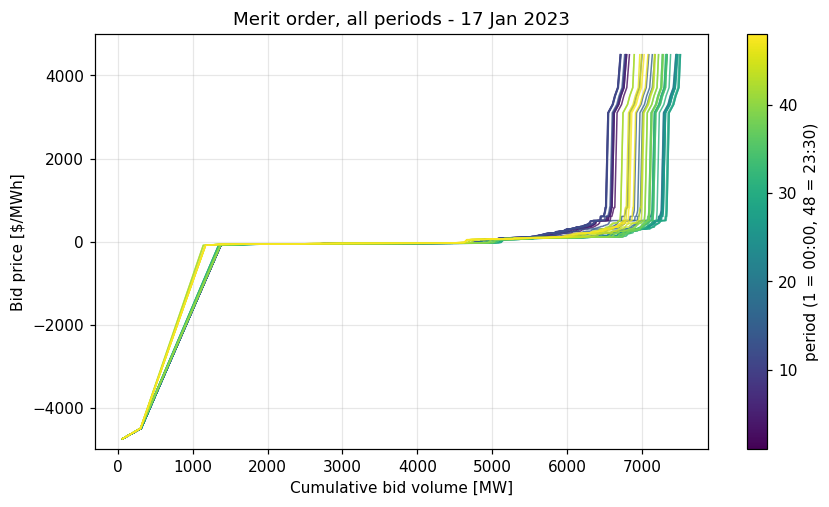

In [113]:
def plot_delayedoffer_day(day, ax=None, ylim=(-5000, 5000)):
    ax = ax or plt.gca()
    day = pd.Timestamp(day)
    cmap = plt.get_cmap("viridis")
    for p in range(1, 49):
        g = delayedoffer.loc[day + pd.Timedelta(minutes=30 * (p - 1))]
        ax.plot(g["cum_volume"], g["bid_price"], color=cmap(p / 48), lw=1, alpha=.8)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(1, 48))
    plt.colorbar(sm, ax=ax, label="period (1 = 00:00, 48 = 23:30)")
    ax.set(title=f"Merit order, all periods - {day:%d %b %Y}",
           xlabel="Cumulative bid volume [MW]", ylabel="Bid price [$/MWh]", ylim=ylim)
    return ax

def plot_delayedoffer_period(ts, ax=None, ylim=(-5000, 5000)):
    ax = ax or plt.gca()
    ts = pd.Timestamp(ts)
    g = delayedoffer.loc[ts]
    d, price = usep.at[ts, "demand"], usep.at[ts, "usep"]
    ax.plot(g["cum_volume"], g["bid_price"], color="tab:blue", label="bid_price")
    ax.axhline(price, color="red", ls="--", lw=1)
    ax.axvline(d, color="black", ls="--", lw=1)
    ax.text(g["cum_volume"].min(), price, f" published USEP = {price:,.0f}", color="red", va="bottom")
    ax.text(d, ylim[0] * .6, " demand", va="center")
    ax.set(title=f"Merit order for datetime: {ts:%Y-%m-%d %H:%M}",
           xlabel="Cumulative bid volume [MW]", ylabel="Bid price [$/MWh]", ylim=ylim)
    ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.9))
    return ax

fig, ax = plt.subplots(figsize=(9, 5))
plot_delayedoffer_day("2023-01-17", ax)
plt.show()

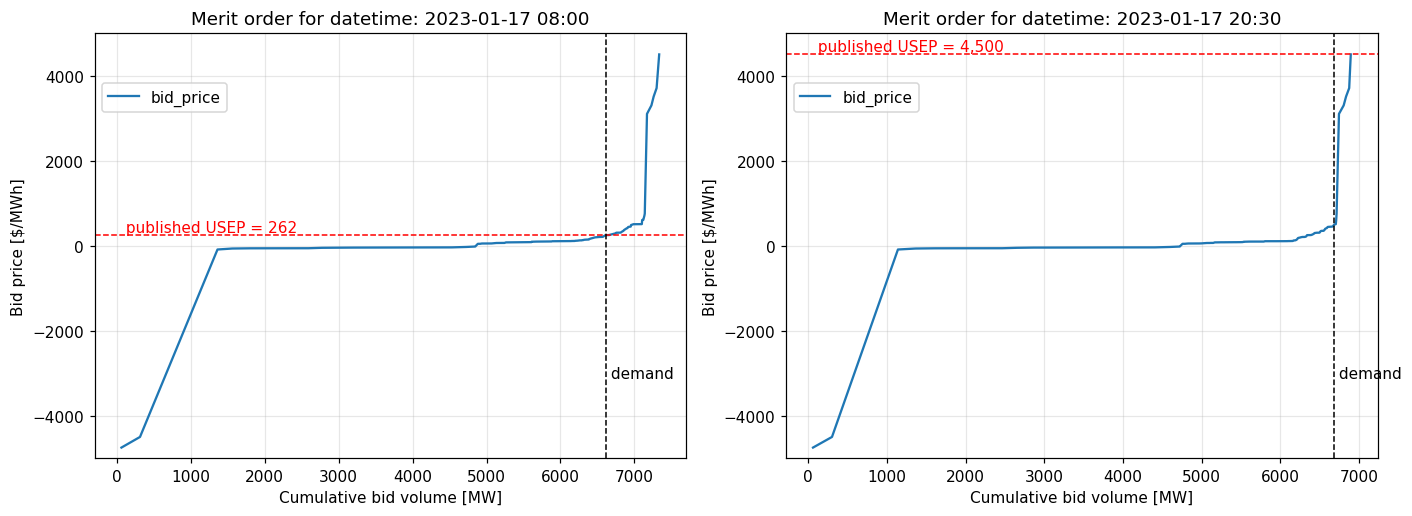

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_delayedoffer_period("2023-01-17 08:00", axes[0])
plot_delayedoffer_period("2023-01-17 20:30", axes[1])
fig.tight_layout(); plt.show()

**Reading the plots**
- Three regimes, as in the brief's example: a steep negative tail, a long flat part around $0-$300, and a near-vertical top up to about $4,500.
- Once demand reaches the steep top, a small change in volume moves the price a lot.
- In the right-hand plot the curve is only about $500 at the demand line, yet the published USEP is $4,500. The $4,500 offer starts about 200 MW *above* demand. 

<a id="sec3"></a>
## 5. Clearing price and unit tests

**Rule:** the price is the cheapest offer step whose cumulative volume is >= demand. `np.searchsorted` does a fast binary search.

**Design decisions:** demand exactly on a step boundary gives that step's price; demand above all offers gives `NaN`; missing demand gives `NaN`; negative demand raises `ValueError`.

In [115]:
def clearing_price(demand, bid_price, cum_volume):
    """Price of the cheapest offer whose cumulative volume >= demand (one period, sorted ascending)."""
    if demand is None or np.isnan(demand):
        return float("nan")
    if demand < 0:
        raise ValueError("demand cannot be negative")
    bid_price = np.asarray(bid_price, dtype=float)
    cum_volume = np.asarray(cum_volume, dtype=float)
    if bid_price.shape != cum_volume.shape or bid_price.size == 0:
        raise ValueError("bid_price and cum_volume must be non-empty and the same length")
    idx = np.searchsorted(cum_volume, demand, side="left")
    return float("nan") if idx >= bid_price.size else float(bid_price[idx])

def estimate_usep(merit, demand):
    """Apply clearing_price to every period (both share a datetime index)."""
    out = {}
    for ts, grp in merit.groupby(level=0):
        d = demand.get(ts, np.nan)
        out[ts] = clearing_price(d, grp["bid_price"].to_numpy(), grp["cum_volume"].to_numpy())
    return pd.Series(out, name="usep_estimate").reindex(demand.index)

# Worked example
ts = pd.Timestamp("2023-01-17 08:00")
g = delayedoffer.loc[ts]; d = usep.at[ts, "demand"]
print(f"demand = {d:,.1f} MW -> estimate = {clearing_price(d, g['bid_price'], g['cum_volume']):,.2f}"
      f"  (published USEP = {usep.at[ts, 'usep']:,.2f})")

demand = 6,620.4 MW -> estimate = 250.00  (published USEP = 261.93)


### Unit tests for `clearing_price`

Covers: a normal marginal offer, demand landing exactly on a step boundary, demand above all offered volume, missing demand, and invalid input.

In [116]:
PRICES = [-100.0, 0.0, 50.0, 200.0]
CUM = [100.0, 300.0, 600.0, 1000.0]  # block volumes: 100, 200, 300, 400

class TestClearingPrice(unittest.TestCase):
    def test_price_set_by_marginal_offer(self):
        self.assertEqual(clearing_price(250, PRICES, CUM), 0.0)
        self.assertEqual(clearing_price(301, PRICES, CUM), 50.0)
        self.assertEqual(clearing_price(999, PRICES, CUM), 200.0)

    def test_demand_exactly_on_block_boundary(self):
        self.assertEqual(clearing_price(300, PRICES, CUM), 0.0)
        self.assertEqual(clearing_price(1000, PRICES, CUM), 200.0)

    def test_zero_demand_returns_cheapest_offer(self):
        self.assertEqual(clearing_price(0, PRICES, CUM), -100.0)

    def test_demand_above_supply_is_nan(self):
        self.assertTrue(math.isnan(clearing_price(1000.1, PRICES, CUM)))

    def test_missing_demand_is_nan(self):
        self.assertTrue(math.isnan(clearing_price(float("nan"), PRICES, CUM)))

    def test_negative_demand_and_bad_input_raise(self):
        with self.assertRaises(ValueError):
            clearing_price(-1, PRICES, CUM)
        with self.assertRaises(ValueError):
            clearing_price(10, PRICES, CUM[:2])

suite = unittest.defaultTestLoader.loadTestsFromTestCase(TestClearingPrice)
unittest.TextTestRunner(verbosity=2).run(suite);

test_demand_above_supply_is_nan (__main__.TestClearingPrice) ... ok
test_demand_exactly_on_block_boundary (__main__.TestClearingPrice) ... ok
test_missing_demand_is_nan (__main__.TestClearingPrice) ... ok
test_negative_demand_and_bad_input_raise (__main__.TestClearingPrice) ... ok
test_price_set_by_marginal_offer (__main__.TestClearingPrice) ... ok
test_zero_demand_returns_cheapest_offer (__main__.TestClearingPrice) ... ok

----------------------------------------------------------------------
Ran 6 tests in 0.008s

OK


<a id="sec4"></a>

 ## 6.Bonus:SQLite
 
 Connect and check version

In [117]:
import sqlite3
print(sqlite3.sqlite_version)   # need 3.25 or higher for window functions
conn = sqlite3.connect("usep.db")

3.32.3


<a id="sec4a"></a>

## 6.1. Load the original CSV files

In [118]:
raw_m = pd.read_csv(DelayedOffer, header=None, dtype=str, skip_blank_lines=False,
                    names=["date_raw", "period_raw", "bid_price_raw", "bid_volume_raw"])
raw_m.to_sql("raw_delayedoffer", conn, if_exists="replace", index=False)

raw_u = pd.read_csv(USEP, dtype=str)
raw_u.columns = ["information_type", "date_raw", "period_raw",
                 "usep_raw", "lcp_raw", "demand_raw", "tcl_raw"]
raw_u.insert(0, "file_row", range(1, len(raw_u) + 1))   # keeps file order, needed to repair
raw_u.to_sql("raw_usep", conn, if_exists="replace", index=False)

print(pd.read_sql("SELECT (SELECT count(*) FROM raw_delayedoffer) AS merit_rows,"
                  " (SELECT count(*) FROM raw_usep) AS usep_rows", conn))

   merit_rows  usep_rows
0      206580       1488


In [132]:
#check the tables in db
print("raw_delayedoffer:")
display(pd.read_sql("SELECT * FROM raw_delayedoffer LIMIT 5", conn))

print("raw_usep:")
display(pd.read_sql("SELECT * FROM raw_usep LIMIT 5", conn))

raw_delayedoffer:


,date_raw,period_raw,bid_price_raw,bid_volume_raw
0,Delayed Offer Stacks_Energy,None,None,None
1,None,None,None,None
2,Date,Period,Lowest to Highest Offer Price ($/MWh),Total Offer Capacity At Specified Offer Price ...
3,01-JAN-2023,1,-4750,84.3
4,01-JAN-2023,1,-4500,324


raw_usep:


,file_row,information_type,date_raw,period_raw,usep_raw,lcp_raw,demand_raw,tcl_raw
0,1,USEP,01 Jan 2023,1,158.62,0,5539.761,0
1,2,USEP,01 Jan 2023,2,147.58,0,5443.353,0
2,3,USEP,01 Jan 2023,3,126.83,0,5384.523,0
3,4,USEP,01 Jan 2023,4,144.53,0,5367.272,0
4,5,USEP,01 Jan 2023,5,144.51,0,5331.369,0


<a id="sec4c"></a>

## 6.2 Clean in CSV files 

In [133]:
#from datetime import datetime

def parse_date(s):
    """'01-JAN-2023' or '01 Jan 2023' -> '2023-01-01'; anything invalid -> None."""
    if s is None:
        return None
    s = s.strip()
    for fmt in ("%d-%b-%Y", "%d %b %Y"):
        try:
            return datetime.strptime(s, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    return None  # e.g. '40 Jan 2023'

def safe_num(s):
    try:
        return float(s)
    except (TypeError, ValueError):
        return None

conn.create_function("parse_date", 1, parse_date)
conn.create_function("safe_num", 1, safe_num)
from datetime import datetime

def parse_date(s):
    """'01-JAN-2023' or '01 Jan 2023' -> '2023-01-01'; anything invalid -> None."""
    if s is None:
        return None
    s = s.strip()
    for fmt in ("%d-%b-%Y", "%d %b %Y"):
        try:
            return datetime.strptime(s, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    return None  # e.g. '40 Jan 2023'

def safe_num(s):
    try:
        return float(s)
    except (TypeError, ValueError):
        return None

conn.create_function("parse_date", 1, parse_date)
conn.create_function("safe_num", 1, safe_num)

In [134]:
conn.executescript("""
DROP TABLE IF EXISTS merit_order;

CREATE TABLE merit_order AS
WITH typed AS (
  SELECT parse_date(date_raw)       AS date,
         CAST(period_raw AS INTEGER) AS period,
         safe_num(bid_price_raw)    AS bid_price,
         safe_num(bid_volume_raw)   AS bid_volume
  FROM raw_delayedOffer
),
valid AS (
  SELECT DISTINCT * FROM typed
  WHERE date IS NOT NULL AND bid_price IS NOT NULL
    AND period BETWEEN 1 AND 48 AND bid_volume > 0
)
SELECT datetime(date || ' 00:00:00', printf('+%d minutes', (period - 1) * 30)) AS datetime,
       date, 
       period,
       bid_price,
       bid_volume,
       SUM(bid_volume) OVER (PARTITION BY date, period ORDER BY bid_price
                             ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cum_volume
FROM valid;

CREATE INDEX idx_merit ON merit_order(datetime, cum_volume);
""")

In [135]:
##To confirm the tables were actually built correctly
display(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))
display(pd.read_sql("SELECT COUNT(*) AS rows FROM merit_order", conn))


,name
0,raw_delayedoffer
1,raw_usep
2,usep
3,merit_order


,rows
0,206577


In [136]:
conn.executescript("""
DROP TABLE IF EXISTS usep;

CREATE TABLE usep AS
WITH typed AS (
  SELECT file_row,
         parse_date(date_raw)        AS date_parsed,
         CAST(period_raw AS INTEGER) AS period_parsed,
         safe_num(usep_raw)   AS usep_v,
         safe_num(lcp_raw)    AS lcp_v,
         safe_num(demand_raw) AS demand_v,
         safe_num(tcl_raw)    AS tcl_v
  FROM raw_usep
),
grouped AS (      -- counts how many valid dates seen so far -> groups rows by the date they belong to
  SELECT *, COUNT(date_parsed) OVER (ORDER BY file_row) AS grp FROM typed
),
repaired AS (
  SELECT file_row,
         MAX(date_parsed) OVER (PARTITION BY grp) AS date,
         date_parsed IS NULL AS date_fixed,
         CASE WHEN period_parsed = 99
              THEN LAG(period_parsed) OVER (ORDER BY file_row) + 1
              ELSE period_parsed END AS period,
         period_parsed = 99 AS period_fixed,
         CASE WHEN period_parsed = 99 THEN NULL ELSE usep_v   END AS usep,
         CASE WHEN period_parsed = 99 THEN NULL ELSE lcp_v    END AS lcp,
         CASE WHEN period_parsed = 99 THEN NULL ELSE demand_v END AS demand,
         CASE WHEN period_parsed = 99 THEN NULL ELSE tcl_v    END AS tcl
  FROM grouped
),
ranked AS (
  SELECT *, ROW_NUMBER() OVER (PARTITION BY date, period ORDER BY file_row) AS rn
  FROM repaired
)
SELECT datetime(date || ' 00:00:00', printf('+%d minutes', (period - 1) * 30)) AS datetime,
       date, period, usep, lcp, demand, tcl, date_fixed, period_fixed
FROM ranked
WHERE rn = 1;
""")

display(pd.read_sql("SELECT * FROM usep WHERE date_fixed OR period_fixed", conn))
display(pd.read_sql("""
SELECT (SELECT count(DISTINCT datetime) FROM merit_order) AS merit_periods,
       (SELECT count(*) FROM usep) AS usep_rows,
       (SELECT count(*) FROM usep WHERE demand IS NULL) AS null_demand""", conn))

,datetime,date,period,usep,lcp,demand,tcl,date_fixed,period_fixed
0,2023-01-07 13:00:00,2023-01-07,27,nan,nan,nan,nan,0,1
1,2023-01-21 12:30:00,2023-01-21,26,112.12,0.00,"5,793.26",0.00,1,0


,merit_periods,usep_rows,null_demand
0,1488,1488,1


In [137]:
#display all the tables in the DB
display(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

,name
0,raw_delayedoffer
1,raw_usep
2,merit_order
3,usep


<a id="sec4d"></a>

## 6.3.Analysis queries

In [138]:
# Daily summary
display(pd.read_sql("""
SELECT date,
       round(avg(usep), 2) AS avg_usep,
       round(max(usep), 2) AS max_usep,
       round(avg(demand), 0) AS avg_demand,
       round(max(demand), 0) AS peak_demand
FROM usep
GROUP BY date
ORDER BY date""", conn).head())

,date,avg_usep,max_usep,avg_demand,peak_demand
0,2023-01-01,150.19,232.49,"5,637.00","6,101.00"
1,2023-01-02,182.22,372.52,"5,720.00","6,314.00"
2,2023-01-03,213.30,404.99,"6,228.00","6,894.00"
3,2023-01-04,235.57,354.24,"6,251.00","6,819.00"
4,2023-01-05,280.02,549.61,"6,254.00","6,875.00"


In [139]:
# Periods priced above the monthly average
display(pd.read_sql("""
SELECT datetime, usep
FROM usep
WHERE usep > (SELECT AVG(usep) FROM usep)
ORDER BY usep DESC""",conn).head(10))

,datetime,usep
0,2023-01-17 20:30:00,"4,500.00"
1,2023-01-09 20:00:00,"3,960.68"
2,2023-01-09 09:30:00,"3,956.49"
3,2023-01-09 09:00:00,"3,852.20"
4,2023-01-17 20:00:00,"3,343.12"
5,2023-01-09 21:30:00,"3,336.62"
6,2023-01-09 19:30:00,"3,333.98"
7,2023-01-09 21:00:00,"3,333.03"
8,2023-01-09 10:30:00,"1,301.07"
9,2023-01-09 14:00:00,"1,100.75"


In [140]:
#Aggrigation full merit table
display(pd.read_sql("""
SELECT COUNT(*)        AS total_offers,
       AVG(bid_price)  AS avg_offer_price,
       SUM(bid_volume) AS total_volume_offered
FROM merit_order
""", conn))

,total_offers,avg_offer_price,total_volume_offered
0,206577,241.81,"10,260,866.40"


In [143]:
#Aggrigation per period
display(pd.read_sql("""
SELECT datetime,
       COUNT(*)        AS num_offers,
       SUM(bid_volume) AS total_volume
FROM merit_order
GROUP BY datetime
ORDER BY datetime
LIMIT 5
""", conn))

,datetime,num_offers,total_volume
0,2023-01-01 00:00:00,109,"6,094.50"
1,2023-01-01 00:30:00,118,"6,080.60"
2,2023-01-01 01:00:00,116,"6,081.80"
3,2023-01-01 01:30:00,115,"6,066.80"
4,2023-01-01 02:00:00,115,"6,056.80"


In [144]:
# This should always match -- SUM() and MAX(cum_volume) are the same number
display(pd.read_sql("""
SELECT datetime,
       SUM(bid_volume)  AS total_via_sum,
       MAX(cum_volume)  AS total_via_cum_volume
FROM merit_order
WHERE datetime = '2023-01-01 06:30:00'
GROUP BY datetime
""", conn))

,datetime,total_via_sum,total_via_cum_volume
0,2023-01-01 06:30:00,"6,165.30","6,165.30"


<a id="sec4e"></a>

## 6.4. Join Tables
Joining 2 table 
The two tables describe the same half-hour periods, but at different levels of detail:

usep has one row per period (1,488 rows total) — the demand and the final price.
merit_order has many rows per period (109–162 offer steps each) — the individual offers that make up that period's stack.

A JOIN lines them up by matching datetime in both tables, so each offer row gets the demand and price that applied at that moment.

In [145]:
#Join
query = """
SELECT u.datetime,
       u.date,
       u.period,
       u.demand,
       u.usep,
       m.bid_price,
       m.bid_volume,
       m.cum_volume
FROM usep u
JOIN merit_order m ON m.datetime = u.datetime
ORDER BY u.datetime, m.bid_price
LIMIT 10;
"""

display(pd.read_sql(query, conn))

,datetime,date,period,demand,usep,bid_price,bid_volume,cum_volume
0,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,"-4,750.00",84.30,84.30
1,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,"-4,500.00",324.00,408.30
2,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,-90.00,854.00,"1,262.30"
3,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,-67.00,200.00,"1,462.30"
4,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,-61.00,280.00,"1,742.30"
5,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,-60.00,685.00,"2,427.30"
6,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,-50.00,20.00,"2,447.30"
7,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,-45.00,420.00,"2,867.30"
8,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,-43.00,215.00,"3,082.30"
9,2023-01-01 00:00:00,2023-01-01,1,"5,539.76",158.62,-40.00,880.00,"3,962.30"


In [146]:
#using the query to match the cheapest offer whose cumulative volume covers demand.
query_marginal = """
SELECT u.datetime,
       u.demand,
       u.usep,
       MIN(m.bid_price) AS usep_estimate,
       m.cum_Volume
FROM usep u
JOIN merit_order m
  ON m.datetime = u.datetime
 AND m.cum_volume >= u.demand
WHERE u.demand IS NOT NULL AND u.usep IS NOT NULL
GROUP BY u.datetime, u.demand, u.usep
ORDER BY u.datetime;
"""

result = pd.read_sql(query_marginal, conn)
display(result.head(20))

,datetime,demand,usep,usep_estimate,cum_volume
0,2023-01-01 00:00:00,"5,539.76",158.62,155.57,"5,562.30"
1,2023-01-01 00:30:00,"5,443.35",147.58,129.20,"5,447.60"
2,2023-01-01 01:00:00,"5,384.52",126.83,121.70,"5,394.40"
3,2023-01-01 01:30:00,"5,367.27",144.53,125.77,"5,378.20"
4,2023-01-01 02:00:00,"5,331.37",144.51,125.77,"5,347.00"
5,2023-01-01 02:30:00,"5,289.51",126.80,121.70,"5,300.80"
6,2023-01-01 03:00:00,"5,232.94",108.48,105.77,"5,247.80"
7,2023-01-01 03:30:00,"5,196.74",106.74,105.77,"5,236.60"
8,2023-01-01 04:00:00,"5,173.40",106.51,105.57,"5,177.20"
9,2023-01-01 04:30:00,"5,180.26",106.74,105.77,"5,219.80"


In [147]:
#Query to show price band
display(pd.read_sql("""
SELECT datetime, usep,
       CASE
           WHEN usep < 100  THEN 'low'
           WHEN usep < 500  THEN 'normal'
           ELSE 'spike'
       END AS price_band
FROM usep
ORDER BY datetime
LIMIT 20""",conn).head(20))

,datetime,usep,price_band
0,2023-01-01 00:00:00,158.62,normal
1,2023-01-01 00:30:00,147.58,normal
2,2023-01-01 01:00:00,126.83,normal
3,2023-01-01 01:30:00,144.53,normal
4,2023-01-01 02:00:00,144.51,normal
5,2023-01-01 02:30:00,126.80,normal
6,2023-01-01 03:00:00,108.48,normal
7,2023-01-01 03:30:00,106.74,normal
8,2023-01-01 04:00:00,106.51,normal
9,2023-01-01 04:30:00,106.74,normal


In [148]:
#Pivot table to see daily count by price band
pivot_by_day_sql = pd.read_sql("""
SELECT date,
       SUM(CASE WHEN usep < 100 THEN 1 ELSE 0 END)                 AS low,
       SUM(CASE WHEN usep >= 100 AND usep < 500 THEN 1 ELSE 0 END) AS normal,
       SUM(CASE WHEN usep >= 500 THEN 1 ELSE 0 END)                AS spike
FROM usep
GROUP BY date
ORDER BY date
""", conn)

display(pivot_by_day_sql)



,date,low,normal,spike
0,2023-01-01,0,48,0
1,2023-01-02,0,48,0
2,2023-01-03,0,48,0
3,2023-01-04,1,47,0
4,2023-01-05,1,40,7
5,2023-01-06,0,46,2
6,2023-01-07,0,47,0
7,2023-01-08,0,44,4
8,2023-01-09,0,18,30
9,2023-01-10,0,46,2


In [149]:
#heigest spike day
top_spike_day = pivot_by_day_sql.loc[pivot_by_day_sql["spike"].idxmax()]
print(f"\nHighest-spike day: {top_spike_day['date']} with {top_spike_day['spike']} spike periods")


Highest-spike day: 2023-01-09 with 30 spike periods


In [150]:
# Median USEP (SQLite has no MEDIAN()): the middle value(s) of the ordered, ranked list
median_usep = pd.read_sql("""
WITH ordered AS (
  SELECT usep, ROW_NUMBER() OVER (ORDER BY usep) AS rn, COUNT(*) OVER () AS n
  FROM usep WHERE usep IS NOT NULL)
SELECT AVG(usep) AS median FROM ordered
WHERE rn IN ((n + 1) / 2, (n + 2) / 2)""", conn).iloc[0, 0]
print("median USEP:", median_usep)

# Price spikes (> 5x median)
display(pd.read_sql(f"""
SELECT datetime, usep, round(demand, 0) AS demand,
       round(usep / {median_usep}, 1) AS x_median
FROM usep WHERE usep > 5 * {median_usep} ORDER BY usep DESC""", conn))


median USEP: 177.09


,datetime,usep,demand,x_median
0,2023-01-17 20:30:00,"4,500.00","6,679.00",25.40
1,2023-01-09 20:00:00,"3,960.68","6,777.00",22.40
2,2023-01-09 09:30:00,"3,956.49","6,880.00",22.30
3,2023-01-09 09:00:00,"3,852.20","6,875.00",21.80
4,2023-01-17 20:00:00,"3,343.12","6,737.00",18.90
5,2023-01-09 21:30:00,"3,336.62","6,518.00",18.80
6,2023-01-09 19:30:00,"3,333.98","6,828.00",18.80
7,2023-01-09 21:00:00,"3,333.03","6,649.00",18.80
8,2023-01-09 10:30:00,"1,301.07","6,872.00",7.30
9,2023-01-09 14:00:00,"1,100.75","6,925.00",6.20


<a id="sec6"></a>

## Summary

Data quality
- Merit order file needed 2 junk lines (a title row and a blank row) skipped
  before loading — no issues in the data itself after that.
- USEP file had two corrupted rows — a placeholder on 7 Jan and an invalid date
  on 21 Jan — both repaired using the surrounding rows.
- Three periods on 9 Jan had a price higher than every offer in the stack,
  which the data can't explain.
